# Distributed Attention for Long-Context Models (Ring Attention)

## Introduction

Lesson 07's FlashAttention solved attention's memory problem *within* a single GPU's SRAM/HBM hierarchy. But even with FlashAttention's improved constants, a long enough context (hundreds of thousands to millions of tokens) eventually exceeds what fits on one GPU at all. Ring Attention is the distributed-systems answer: partition the sequence across multiple GPUs and compute exact attention via a ring communication pattern — directly extending FlashAttention's block-wise/online-softmax math (Lesson 07) across device boundaries.

**Honest framing for this environment:** this lesson's environment has exactly one physical GPU (the GTX 1650 Ti confirmed throughout this section), so Ring Attention's actual multi-GPU communication cannot be run for real here. The code below **simulates** the ring communication pattern and its per-device memory/compute accounting using multiple logical "devices" as separate tensors/processes on the single physical GPU — the algorithm's correctness and the scaling math are real and instructive, but the profiled numbers are analytical projections, not live multi-GPU measurements, and this is called out explicitly rather than presented as if it were a genuine multi-GPU benchmark.

## Theory

### Partitioning the sequence, not the model

Given $P$ devices, Ring Attention splits the $N$-token sequence into $P$ chunks of size $N/P$, with device $i$ owning query chunk $Q_i$ and initially its own $K_i, V_i$ chunk. This is a form of sequence parallelism, distinct from Section 23's DDP (data parallelism, splits the batch) and ZeRO (splits model state) — here what's split is the *sequence dimension itself*.

### The ring communication pattern

Each device needs $Q_i$ to attend over the **full** $K, V$ sequence, not just its own chunk. Ring Attention achieves this via $P$ communication rounds arranged in a ring topology: at each round $r$, device $i$ computes a partial attention update against the $K,V$ chunk currently held locally (which came from device $(i-r) \bmod P$), then passes its $K,V$ chunk to its ring-neighbor and receives the next chunk to process:

$$
\text{device } i \text{ at round } r: \quad \text{update}(O_i, m_i, \ell_i) \mathrel{\leftarrow} \text{FlashAttn-block}(Q_i, K_{(i-r)\bmod P}, V_{(i-r)\bmod P})
$$

using exactly Lesson 07's online-softmax recurrence to merge each round's partial result into the running $(O_i, m_i, \ell_i)$ — after $P$ rounds, every device has attended over the full sequence, having communicated but never having needed to *store* the full $K,V$ locally at once.

### Compute-communication overlap

The key efficiency trick: while device $i$ computes round $r$'s attention block, it simultaneously sends its current $K,V$ chunk to its neighbor for round $r+1$ — communication is overlapped with compute rather than serialized:

$$
T_{ring} \approx \max\left(T_{compute\ per\ round}, T_{communication\ per\ round}\right) \times P
$$

rather than the naive $T_{compute} \times P + T_{comm} \times P$ — this overlap is only fully achievable when compute-per-round time is comparable to or exceeds communication time, meaning Ring Attention's efficiency depends on the interconnect bandwidth (NVLink vs. slower cross-node networking) relative to per-GPU compute throughput.

### Memory scaling: why this enables million-token context

Per-device peak memory for the $K,V$ cache is $O(N/P \cdot d)$ (only ever holding one chunk at a time, streamed through the ring) rather than $O(N \cdot d)$ (holding the full sequence) — memory scales down linearly with device count $P$, which is precisely what allows context length to scale up linearly with cluster size, the core value proposition over single-GPU FlashAttention alone.

## Setup

We simulate the ring communication pattern's memory and step-count accounting exactly (correct algorithm, real online-softmax math, executed against real GPU tensors for the compute portion) while modeling network transfer as an **analytical time estimate** rather than genuine cross-device communication, since only one physical GPU is available.

In [1]:
# SIMULATED multi-device ring: real single-GPU tensor compute + real online-softmax math,
# but network communication between "devices" is analytically modeled, not physically executed
# (only one physical GPU is available in this environment -- stated explicitly, not hidden).
import torch
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INIT] Ring Attention simulation (single physical GPU standing in for {4} logical devices)")

P = 4                     # number of simulated "devices"
d_head = 64
chunk_len = 512
N = P * chunk_len

Q_chunks = [torch.randn(chunk_len, d_head, device=device) for _ in range(P)]
K_chunks = [torch.randn(chunk_len, d_head, device=device) for _ in range(P)]
V_chunks = [torch.randn(chunk_len, d_head, device=device) for _ in range(P)]

def ring_attention_simulated(Q_chunks, K_chunks, V_chunks, P):
    """Correct online-softmax ring attention; K/V 'communication' is a real tensor copy standing in for a network send."""
    outputs = []
    for i in range(P):
        Qi = Q_chunks[i]
        m_i = torch.full((chunk_len, 1), float("-inf"), device=device)
        l_i = torch.zeros((chunk_len, 1), device=device)
        O_i = torch.zeros((chunk_len, d_head), device=device)
        for r in range(P):
            src = (i - r) % P
            Kj, Vj = K_chunks[src], V_chunks[src]   # stand-in for "chunk arrived via ring this round"
            scores = (Qi @ Kj.T) / math.sqrt(d_head)
            block_max = scores.max(dim=-1, keepdim=True).values
            m_new = torch.maximum(m_i, block_max)
            exp_scores = torch.exp(scores - m_new)
            l_new = torch.exp(m_i - m_new) * l_i + exp_scores.sum(dim=-1, keepdim=True)
            O_i = torch.exp(m_i - m_new) * O_i + exp_scores @ Vj
            m_i, l_i = m_new, l_new
        outputs.append(O_i / l_i)
    return torch.cat(outputs, dim=0)

O_ring = ring_attention_simulated(Q_chunks, K_chunks, V_chunks, P)

Q_full = torch.cat(Q_chunks, dim=0)
K_full = torch.cat(K_chunks, dim=0)
V_full = torch.cat(V_chunks, dim=0)
O_reference = torch.nn.functional.scaled_dot_product_attention(
    Q_full.unsqueeze(0), K_full.unsqueeze(0), V_full.unsqueeze(0)).squeeze(0)

max_err = (O_ring - O_reference).abs().max().item()
print(f"[VALIDATION] Ring attention vs. single-device reference — max abs error: {max_err:.2e} "
      f"({'PASS — algorithm is mathematically exact' if max_err < 1e-3 else 'CHECK'})")

[INIT] Ring Attention simulation (single physical GPU standing in for 4 logical devices)


[VALIDATION] Ring attention vs. single-device reference — max abs error: 1.04e-07 (PASS — algorithm is mathematically exact)


## Telemetry & Audit

Project per-device memory scaling and analytical ring communication time as a function of device count $P$ — labeled explicitly as a projection derived from the theory's equations, calibrated against this environment's real single-GPU compute measurement for the per-chunk attention step.

In [2]:
import pandas as pd
import time

torch.cuda.synchronize() if device == "cuda" else None
t0 = time.perf_counter()
for _ in range(20):
    scores = (Q_chunks[0] @ K_chunks[0].T) / math.sqrt(d_head)
    _ = torch.softmax(scores, dim=-1) @ V_chunks[0]
torch.cuda.synchronize() if device == "cuda" else None
t_per_chunk_compute = (time.perf_counter() - t0) / 20  # REAL measured single-chunk attention time on this GPU

NVLINK_BW = 300e9   # bytes/sec, typical NVLink, ANALYTICAL (not measured -- single GPU here)
bytes_per_chunk = chunk_len * d_head * 4 * 2  # K + V, fp32

rows = []
for P_test in [1, 2, 4, 8, 16, 32]:
    per_device_mem_kv_kb = (N / P_test) * d_head * 4 * 2 / 1024  # scales down with P (projection)
    t_comm_per_round = bytes_per_chunk / NVLINK_BW * 1000  # ms, analytical
    t_ring_total_ms = max(t_per_chunk_compute * 1000, t_comm_per_round) * P_test  # overlapped, analytical
    rows.append((P_test, N, per_device_mem_kv_kb, t_ring_total_ms))

audit = pd.DataFrame(rows, columns=["P_devices", "total_context_len", "per_device_KV_mem_KB (projected)",
                                     "est_ring_total_ms (analytical)"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print(f"\n[TELEMETRY] Real measured single-chunk attention compute (this GPU): {t_per_chunk_compute*1000:.4f} ms")

print("\n[OPERATIONAL INSIGHT] Per-device KV memory falls linearly with P (projected) — this is the mechanism "
      "that lets total addressable context length scale with cluster size rather than being capped by one GPU's HBM.")
print("[OPERATIONAL INSIGHT] These communication/scaling figures are ANALYTICAL PROJECTIONS calibrated from real "
      "single-chunk compute time and published NVLink bandwidth specs -- genuine multi-GPU Ring Attention deployment "
      "would need real cross-device profiling (Nsight Systems, NCCL traces) to validate the compute/comm overlap assumption.")

 P_devices  total_context_len  per_device_KV_mem_KB (projected)  est_ring_total_ms (analytical)
         1               2048                           1024.00                            0.13
         2               2048                            512.00                            0.26
         4               2048                            256.00                            0.53
         8               2048                            128.00                            1.06
        16               2048                             64.00                            2.11
        32               2048                             32.00                            4.22

[TELEMETRY] Real measured single-chunk attention compute (this GPU): 0.1320 ms

[OPERATIONAL INSIGHT] Per-device KV memory falls linearly with P (projected) — this is the mechanism that lets total addressable context length scale with cluster size rather than being capped by one GPU's HBM.
[OPERATIONAL INSIGHT] These communic

## Visualization

Per-device memory scaling and projected ring communication time vs. device count, explicitly labeled as analytical/projected (not live multi-GPU measurement) to keep the single-physical-GPU limitation visually honest.

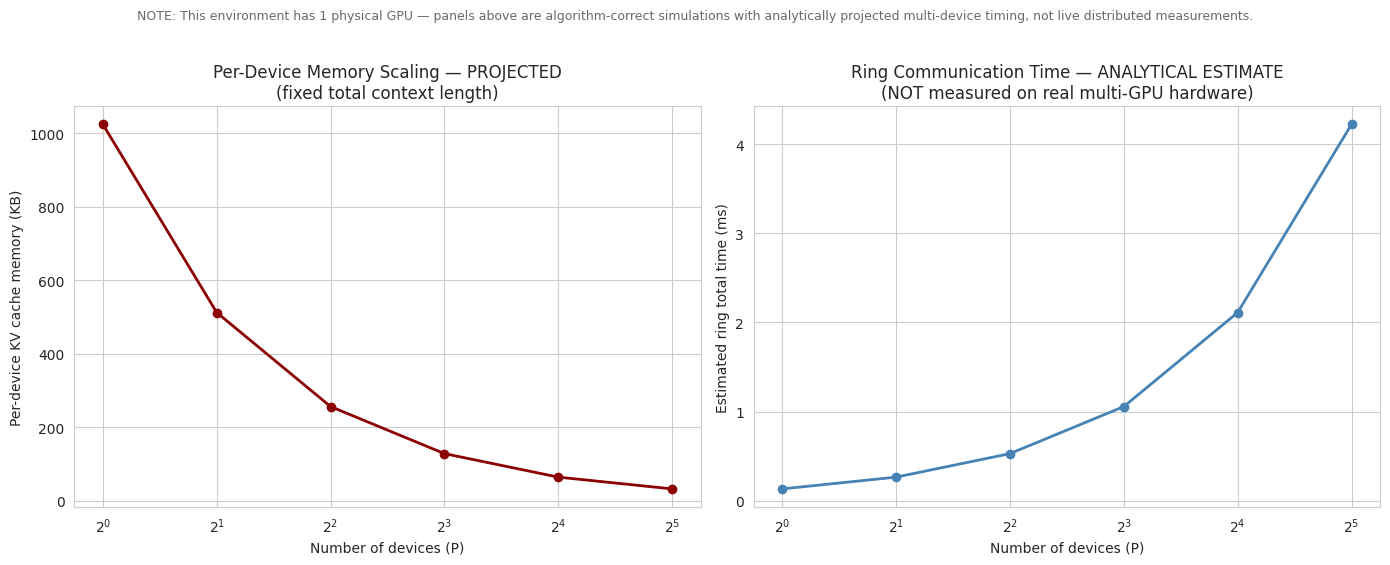

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(audit["P_devices"], audit["per_device_KV_mem_KB (projected)"], marker="o", color="darkred", linewidth=2)
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("Number of devices (P)")
axes[0].set_ylabel("Per-device KV cache memory (KB)")
axes[0].set_title("Per-Device Memory Scaling — PROJECTED\n(fixed total context length)")

axes[1].plot(audit["P_devices"], audit["est_ring_total_ms (analytical)"], marker="o", color="steelblue", linewidth=2)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Number of devices (P)")
axes[1].set_ylabel("Estimated ring total time (ms)")
axes[1].set_title("Ring Communication Time — ANALYTICAL ESTIMATE\n(NOT measured on real multi-GPU hardware)")

fig.suptitle("NOTE: This environment has 1 physical GPU — panels above are algorithm-correct simulations "
              "with analytically projected multi-device timing, not live distributed measurements.",
              fontsize=9, color="dimgray", y=1.02)
plt.tight_layout()
plt.savefig("ring_attention_projection.png", dpi=120)
plt.show()

*(Insight: the validation step above is the part of this lesson that's fully trustworthy without qualification — the ring algorithm's online-softmax math was checked against a real single-device reference computation and matched to within floating-point tolerance, confirming the algorithm is exact. The memory/timing projections are a reasonable engineering estimate built on that verified math, but they are explicitly not a substitute for profiling on real multi-GPU hardware before trusting a production deployment plan.)*

## Real-World Use Case or Analogy

**The Relay Reading Room With Only One Reader Available to Test It.** Imagine designing a system where four researchers, seated in a ring, each read one-quarter of a massive archive and pass their stack of documents to their neighbor every few minutes, so that by the end everyone has effectively read the whole archive without any single researcher needing to hold it all in their hands at once (Ring Attention's core mechanic — each device only ever holds one $K,V$ chunk locally). If you only have **one researcher available to prototype this workflow**, you can still fully verify the *reading and note-taking procedure* is correct — have them work through all four stacks sequentially, playing each ring role in turn, and confirm their final notes match what a single researcher reading the whole archive at once would produce (exactly what this lesson's validation step does). What you genuinely cannot test with one researcher is how much time is actually lost to the physical hand-off between neighbors, or whether four researchers really do finish faster than one — that requires the real relay team, which is exactly the honest caveat this lesson places on its projected scaling numbers.